In [ ]:
# Data-path configuration (see ../paths.py and ../DATA.md).
# Set the SCREAM_AUTOTUNE_DATA env var to point at the unpacked Zenodo
# data deposit; defaults to <repo>/data. Assumes this notebook is run
# from its own directory (the Jupyter default).
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import paths


# Surrogate KFolds — Visualization
Loads the `CV_summary_*.json` saved by `surrogate_kfolds_masked.py` and plots model performance across GP, CNN, RF, MLR, and Spline.

Aggregation strategy: average folds within each seed → per-seed mean; then mean ± std across seeds.

In [4]:
import glob
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Configuration
Set `save_dir` to the directory where `surrogate_kfolds_masked.py` wrote its output. The most recent `CV_summary_*.json` will be loaded automatically.

In [5]:
save_dir = str(paths.CV_RESULTS_DIR / "10seeds_GPCNNRFMLRSR_raw")

# Auto-find most recent CV summary JSON, or override manually
matches  = sorted(glob.glob(os.path.join(save_dir, 'CV_summary_*.json')))
cv_file  = matches[-1] if matches else None
# cv_file = os.path.join(save_dir, 'CV_summary_TIMESTAMP.json')

print(f'Loading: {cv_file}')
with open(cv_file) as f:
    cv_summary = json.load(f)

# Flatten {model: [fold_dict, ...]} into a single DataFrame
records = []
for model, fold_list in cv_summary.items():
    records.extend(fold_list)
df = pd.DataFrame(records)

print(f'Loaded {len(df)} records')
print(f'Models : {sorted(df["model"].unique())}')
if 'seed' in df.columns:
    print(f'Seeds  : {sorted(df["seed"].unique())}')
print(f'Folds  : {sorted(df["fold"].unique())}')
df.head()

Loading: /global/cfs/cdirs/e3sm/jpaige3/ESEm/CV_Saved_Model_Data_masked/10seeds_GPCNNRFMLRSR_raw/CV_summary_2026-05-21_10-18-12.json
Loaded 250 records
Models : ['CNN', 'GP', 'MLR', 'RF', 'Spline']
Seeds  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Folds  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,model,seed,fold,PCP_train_r2_norm,PCP_train_rmse_norm,PCP_train_r2_phys,PCP_train_rmse_phys,PCP_train_r2_norm_raw,PCP_train_r2_phys_raw,TLWP_train_r2_norm,...,OSR_test_r2_phys,OSR_test_rmse_phys,OSR_test_r2_norm_raw,OSR_test_r2_phys_raw,OLR_test_r2_norm,OLR_test_rmse_norm,OLR_test_r2_phys,OLR_test_rmse_phys,OLR_test_r2_norm_raw,OLR_test_r2_phys_raw
0,GP,0,0,0.971574,0.156499,0.971574,5.344027e-10,"[0.9732715487480164, 0.9901086688041687, 0.992...","[0.973271554560735, 0.9901086541975539, 0.9923...",0.980870,...,0.844727,2.996646,"[0.9514238834381104, 0.9408079981803894, 0.921...","[0.9514239246872319, 0.9408080108783892, 0.921...",0.765198,0.334690,0.765198,2.159358,"[0.8685464262962341, 0.8766931295394897, 0.848...","[0.8685464582663686, 0.876693173422008, 0.8489..."
1,GP,0,1,0.989251,0.094497,0.989252,2.841034e-10,"[0.9881947636604309, 0.9967175722122192, 0.997...","[0.9881947511126316, 0.9967175930934357, 0.997...",0.994087,...,0.511660,5.086999,"[0.8495820760726929, 0.8604899644851685, 0.827...","[0.8495820528736305, 0.8604899668966844, 0.827...",-0.253562,0.646227,-0.253562,3.913553,"[0.42651844024658203, 0.5438165664672852, 0.47...","[0.4265183513595865, 0.5438165170047525, 0.471..."
2,GP,0,2,0.989672,0.096399,0.989672,3.348347e-10,"[0.9893548488616943, 0.9963108897209167, 0.996...","[0.9893548402706174, 0.9963108919970678, 0.996...",0.990898,...,0.529449,6.408921,"[0.8347808122634888, 0.8196634650230408, 0.666...","[0.8347808025727669, 0.8196634747941478, 0.666...",0.039419,0.788342,0.039419,5.161461,"[0.2764178514480591, 0.45614415407180786, 0.36...","[0.27641790186181403, 0.45614419158990915, 0.3..."
3,GP,0,3,1.000000,0.000005,1.000000,1.524893e-14,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.9999999999670117, 0.9999999999907135, 0.999...",1.000000,...,0.657074,7.439748,"[0.7960348725318909, 0.7368321418762207, 0.766...","[0.7960348898780907, 0.7368321117649714, 0.766...",0.582934,1.187507,0.582934,6.386365,"[0.6826947927474976, 0.7225795984268188, 0.677...","[0.6826947687748621, 0.722579539426738, 0.6772..."
4,GP,0,4,0.989640,0.094723,0.989640,2.988173e-10,"[0.9907586574554443, 0.9960729479789734, 0.996...","[0.9907586335788615, 0.9960729532474187, 0.996...",0.990797,...,0.617167,6.314801,"[0.7148956060409546, 0.6990849375724792, 0.674...","[0.7148956414991998, 0.699084917701909, 0.6740...",0.041580,0.784465,0.041580,4.989060,"[-0.21604347229003906, 0.3014492392539978, 0.2...","[-0.21604382648329046, 0.3014492873766489, 0.2..."


## Aggregate: mean ± std across seeds
Step 1 — for each (model, seed), average the metric across its 5 folds.  
Step 2 — across the resulting per-seed means, compute mean and std.

In [17]:
VAR_NAMES  = ['PCP', 'TLWP', 'OSR', 'OLR']
UNITS = {
    'PCP':  'mm/day',
    'TLWP': 'kg/m$^{2}$',
    'OSR':  'W/m$^{2}$',
    'OLR':  'W/m$^{2}$',
}
# PCP is stored as a flux in kg m^-2 s^-1; for water (density 1000 kg/m^3) that's
# equivalent to mm/s, so multiply by 86400 s/day to get mm/day.
SECONDS_PER_DAY = 86400
UNIT_SCALE = {'PCP': SECONDS_PER_DAY}

MODEL_ORDER = ['GP', 'CNN', 'RF', 'MLR', 'Spline']
models_present = [m for m in MODEL_ORDER if m in df['model'].unique()]

group_cols = ['model', 'seed'] if 'seed' in df.columns else ['model']

# Exclude list-valued columns (raw per-gridpoint R² arrays) — keep only scalar metrics
metric_cols = [
    c for c in df.columns
    if c not in ('model', 'seed', 'fold')
    and not c.endswith('_raw')
    and df[c].apply(lambda x: np.isscalar(x)).all()
]

# Step 1: mean across folds within each (model, seed)
seed_means = df.groupby(group_cols)[metric_cols].mean().reset_index()

# Step 2: mean and std across seeds for each model
agg_mean = seed_means.groupby('model')[metric_cols].mean()
agg_std  = seed_means.groupby('model')[metric_cols].std(ddof=1)

print('=== Mean across seeds (test R², physical space) ===')
test_phys_cols = [c for c in metric_cols if 'test_r2_phys' in c]
display_mean = agg_mean[test_phys_cols].copy()
display_mean['Mean'] = display_mean.mean(axis=1)
display(display_mean.round(3))

print('\n=== Std across seeds ===')
display_std = agg_std[test_phys_cols].copy()
display_std['Mean'] = display_std.mean(axis=1)
display(display_std.round(3))

=== Mean across seeds (test R², physical space) ===


,PCP_test_r2_phys,TLWP_test_r2_phys,OSR_test_r2_phys,OLR_test_r2_phys,Mean
model,,,,,
CNN,0.451,0.559,0.413,0.409,0.458
GP,0.629,0.792,0.680,0.293,0.599
MLR,0.293,0.572,0.310,0.117,0.323
RF,0.526,0.332,0.587,0.273,0.430
Spline,0.507,0.785,0.519,-0.024,0.447



=== Std across seeds ===


,PCP_test_r2_phys,TLWP_test_r2_phys,OSR_test_r2_phys,OLR_test_r2_phys,Mean
model,,,,,
CNN,0.031,0.024,0.060,0.060,0.044
GP,0.030,0.021,0.031,0.097,0.045
MLR,0.078,0.027,0.063,0.138,0.076
RF,0.030,0.027,0.047,0.113,0.054
Spline,0.065,0.012,0.054,0.161,0.073


In [18]:
print('=== Mean across seeds (test R², normalized space) ===')
test_norm_cols = [c for c in metric_cols if 'test_r2_norm' in c]
display_mean = agg_mean[test_norm_cols].copy()
display_mean['Mean'] = display_mean.mean(axis=1)
display(display_mean.round(3))

print('\n=== Std across seeds ===')
display_std = agg_std[test_norm_cols].copy()
display_std['Mean'] = display_std.mean(axis=1)
display(display_std.round(3))

=== Mean across seeds (test R², normalized space) ===


,PCP_test_r2_norm,TLWP_test_r2_norm,OSR_test_r2_norm,OLR_test_r2_norm,Mean
model,,,,,
CNN,0.451,0.559,0.413,0.409,0.458
GP,0.629,0.792,0.680,0.293,0.599
MLR,0.293,0.572,0.310,0.117,0.323
RF,NaN,NaN,NaN,NaN,NaN
Spline,0.507,0.785,0.519,-0.024,0.447



=== Std across seeds ===


,PCP_test_r2_norm,TLWP_test_r2_norm,OSR_test_r2_norm,OLR_test_r2_norm,Mean
model,,,,,
CNN,0.031,0.024,0.060,0.060,0.044
GP,0.030,0.021,0.031,0.097,0.045
MLR,0.078,0.027,0.063,0.138,0.076
RF,NaN,NaN,NaN,NaN,NaN
Spline,0.065,0.012,0.054,0.161,0.073


In [19]:
print('=== Mean across seeds (test RMSE, physical space) ===')
test_phys_cols = [c for c in metric_cols if 'test_rmse_phys' in c]
display_mean = agg_mean[test_phys_cols].copy()
display(display_mean)

print('\n=== Std across seeds ===')
display_std = agg_std[test_phys_cols].copy()
display(display_std)

=== Mean across seeds (test RMSE, physical space) ===


,PCP_test_rmse_phys,TLWP_test_rmse_phys,OSR_test_rmse_phys,OLR_test_rmse_phys
model,,,,
CNN,2.556911e-09,0.013111,7.125492,4.266375
GP,1.530511e-09,0.008885,4.935874,4.035159
MLR,2.754403e-09,0.012431,7.521004,4.765485
RF,2.205223e-09,0.016139,5.672022,4.475924
Spline,1.830418e-09,0.009057,5.956939,4.700224



=== Std across seeds ===


,PCP_test_rmse_phys,TLWP_test_rmse_phys,OSR_test_rmse_phys,OLR_test_rmse_phys
model,,,,
CNN,5.550193e-11,0.000205,0.315733,0.102759
GP,5.143527e-11,0.000365,0.305930,0.238661
MLR,3.422531e-11,0.000277,0.158689,0.099524
RF,5.452658e-11,0.000293,0.129834,0.137590
Spline,4.874286e-11,0.000292,0.211413,0.201097


In [20]:
print('=== Mean across seeds (test RMSE, norm space) ===')
test_norm_cols = [c for c in metric_cols if 'test_rmse_norm' in c]
display_mean = agg_mean[test_norm_cols].copy()
display_mean['Mean'] = display_mean.mean(axis=1)
display(display_mean.round(3))

print('\n=== Std across seeds ===')
display_std = agg_std[test_norm_cols].copy()
display_std['Mean'] = display_std.mean(axis=1)
display(display_std.round(3))

=== Mean across seeds (test RMSE, norm space) ===


,PCP_test_rmse_norm,TLWP_test_rmse_norm,OSR_test_rmse_norm,OLR_test_rmse_norm,Mean
model,,,,,
CNN,0.727,0.648,0.747,0.771,0.723
GP,0.500,0.431,0.508,0.687,0.532
MLR,0.780,0.625,0.778,0.837,0.755
RF,NaN,NaN,NaN,NaN,NaN
Spline,0.576,0.441,0.610,0.795,0.605



=== Std across seeds ===


,PCP_test_rmse_norm,TLWP_test_rmse_norm,OSR_test_rmse_norm,OLR_test_rmse_norm,Mean
model,,,,,
CNN,0.010,0.012,0.025,0.016,0.016
GP,0.013,0.015,0.031,0.039,0.025
MLR,0.006,0.015,0.016,0.016,0.013
RF,NaN,NaN,NaN,NaN,NaN
Spline,0.017,0.013,0.020,0.029,0.020


## Plot 1 — Model comparison: one panel per variable
Out-of-sample R² in physical space for each model, with ±1 std error bars.

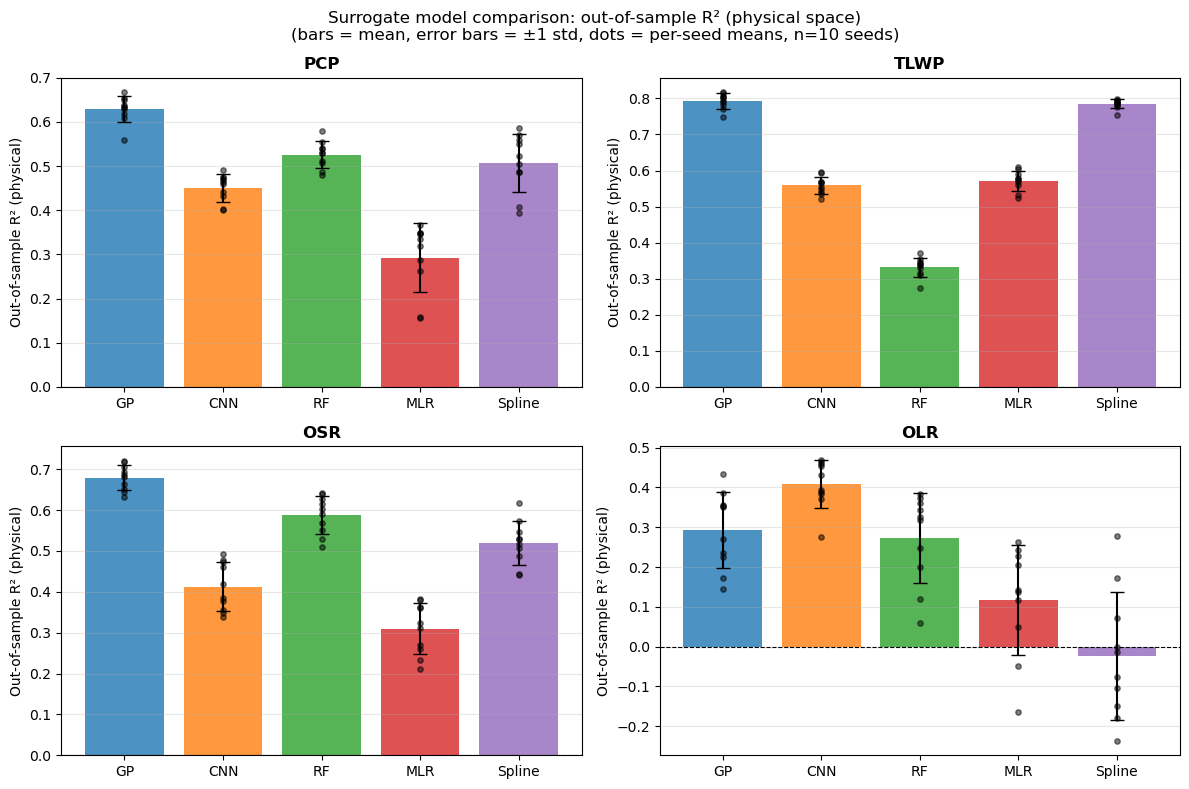

In [21]:
colors_model = {
    'GP':     '#1f77b4',
    'CNN':    '#ff7f0e',
    'RF':     '#2ca02c',
    'MLR':    '#d62728',
    'Spline': '#9467bd',
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
axes = axes.flatten()
x = np.arange(len(models_present))
n_seeds = seed_means['seed'].nunique() if 'seed' in seed_means.columns else '?'

for ax, var in zip(axes, VAR_NAMES):
    col = f'{var}_test_r2_phys'
    means = [agg_mean.loc[m, col] if col in agg_mean.columns and m in agg_mean.index else np.nan
             for m in models_present]
    stds  = [agg_std.loc[m, col]  if col in agg_std.columns  and m in agg_std.index  else 0
             for m in models_present]

    bar_colors = [colors_model.get(m, 'gray') for m in models_present]
    bars = ax.bar(x, means, yerr=stds, color=bar_colors, alpha=0.8,
                  capsize=5, error_kw={'linewidth': 1.5})

    # overlay individual seed-mean dots
    for i, m in enumerate(models_present):
        if col not in seed_means.columns:
            continue
        pts = seed_means.loc[seed_means['model'] == m, col].values
        ax.scatter(np.full(len(pts), i), pts, color='black', s=15, alpha=0.5, zorder=3)

    ax.set_title(var, fontweight='bold')
    ax.set_ylabel('Out-of-sample R² (physical)')
    ax.set_xticks(x)
    ax.set_xticklabels(models_present)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

fig.suptitle(f'Surrogate model comparison: out-of-sample R² (physical space)\n'
             f'(bars = mean, error bars = ±1 std, dots = per-seed means, n={n_seeds} seeds)',
             fontsize=12)
plt.tight_layout()
plt.show()

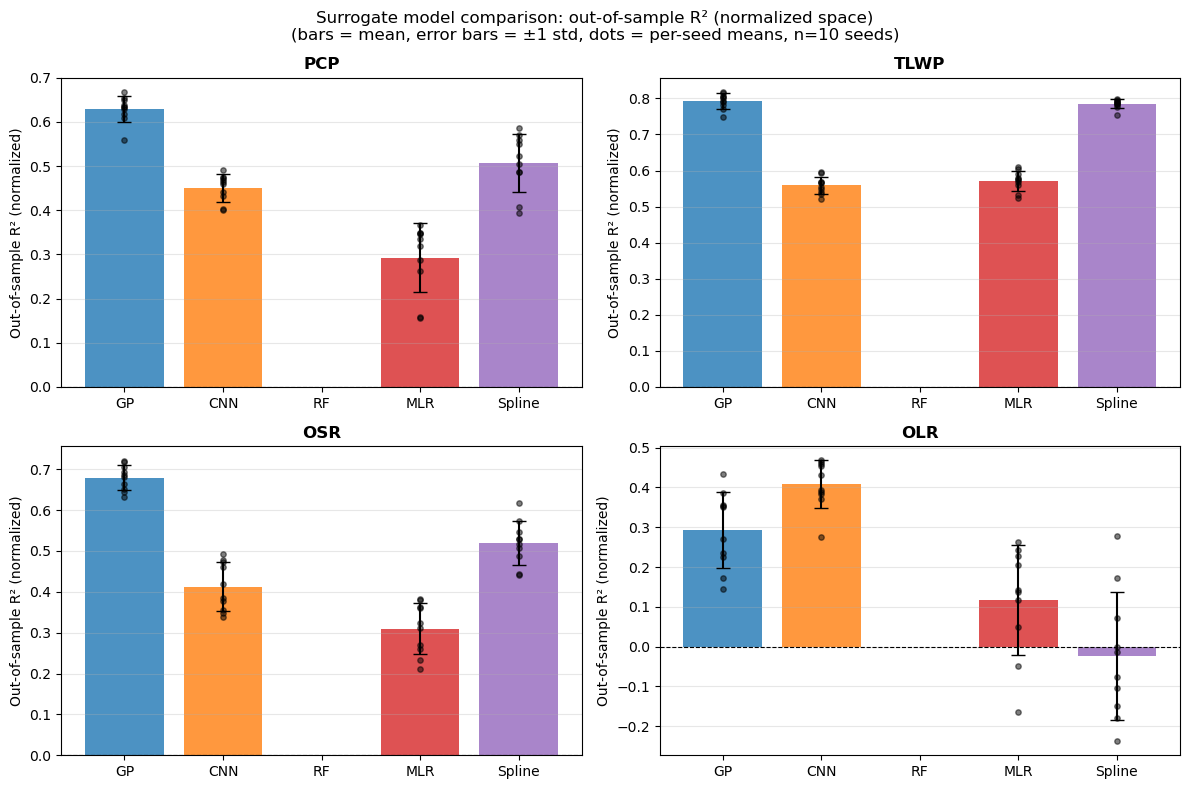

In [23]:
colors_model = {
    'GP':     '#1f77b4',
    'CNN':    '#ff7f0e',
    'RF':     '#2ca02c',
    'MLR':    '#d62728',
    'Spline': '#9467bd',
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
axes = axes.flatten()
x = np.arange(len(models_present))
n_seeds = seed_means['seed'].nunique() if 'seed' in seed_means.columns else '?'

for ax, var in zip(axes, VAR_NAMES):
    col = f'{var}_test_r2_norm'
    means = [agg_mean.loc[m, col] if col in agg_mean.columns and m in agg_mean.index else np.nan
             for m in models_present]
    stds  = [agg_std.loc[m, col]  if col in agg_std.columns  and m in agg_std.index  else 0
             for m in models_present]

    bar_colors = [colors_model.get(m, 'gray') for m in models_present]
    bars = ax.bar(x, means, yerr=stds, color=bar_colors, alpha=0.8,
                  capsize=5, error_kw={'linewidth': 1.5})

    # overlay individual seed-mean dots
    for i, m in enumerate(models_present):
        if col not in seed_means.columns:
            continue
        pts = seed_means.loc[seed_means['model'] == m, col].values
        ax.scatter(np.full(len(pts), i), pts, color='black', s=15, alpha=0.5, zorder=3)

    ax.set_title(var, fontweight='bold')
    ax.set_ylabel('Out-of-sample R² (normalized)')
    ax.set_xticks(x)
    ax.set_xticklabels(models_present)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

fig.suptitle(f'Surrogate model comparison: out-of-sample R² (normalized space)\n'
             f'(bars = mean, error bars = ±1 std, dots = per-seed means, n={n_seeds} seeds)',
             fontsize=12)
plt.tight_layout()
plt.show()

## Plot 2 — Model comparison: all variables on one axes
Grouped bar chart — each group is a variable, bars are models.

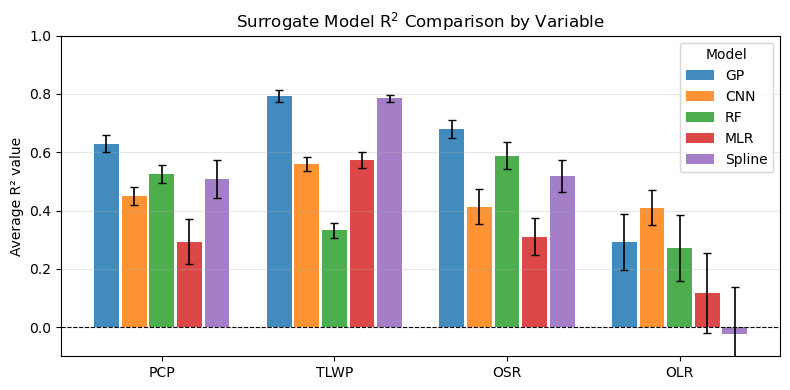

In [24]:
n_models = len(models_present)
n_vars   = len(VAR_NAMES)
width    = 0.8 / n_models
x_base   = np.arange(n_vars)

fig, ax = plt.subplots(figsize=(8, 4))

for i, m in enumerate(models_present):
    offsets = x_base + (i - n_models / 2 + 0.5) * width
    means, stds = [], []
    for var in VAR_NAMES:
        col = f'{var}_test_r2_phys'
        means.append(agg_mean.loc[m, col] if col in agg_mean.columns and m in agg_mean.index else np.nan)
        stds.append(agg_std.loc[m, col]   if col in agg_std.columns  and m in agg_std.index  else 0)
    ax.bar(offsets, means, width=width * 0.9, yerr=stds,
           label=m, color=colors_model.get(m, 'gray'), alpha=0.85,
           capsize=3, error_kw={'linewidth': 1.2})

ax.set_xticks(x_base)
ax.set_xticklabels(VAR_NAMES)
ax.set_ylabel('Average R² value')
ax.set_ylim(-0.1,1)
ax.set_title(f'Surrogate Model R$^2$ Comparison by Variable') #\n'
             #f'(mean ± 1 std across {n_seeds} seeds, each seed = mean of 5 CV folds)')
ax.legend(title='Model')
ax.grid(axis='y', alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

## Plot 3 — Normalized vs physical R² (GP and CNN only)
For models that report both spaces, compare normalized and physical R² side-by-side.

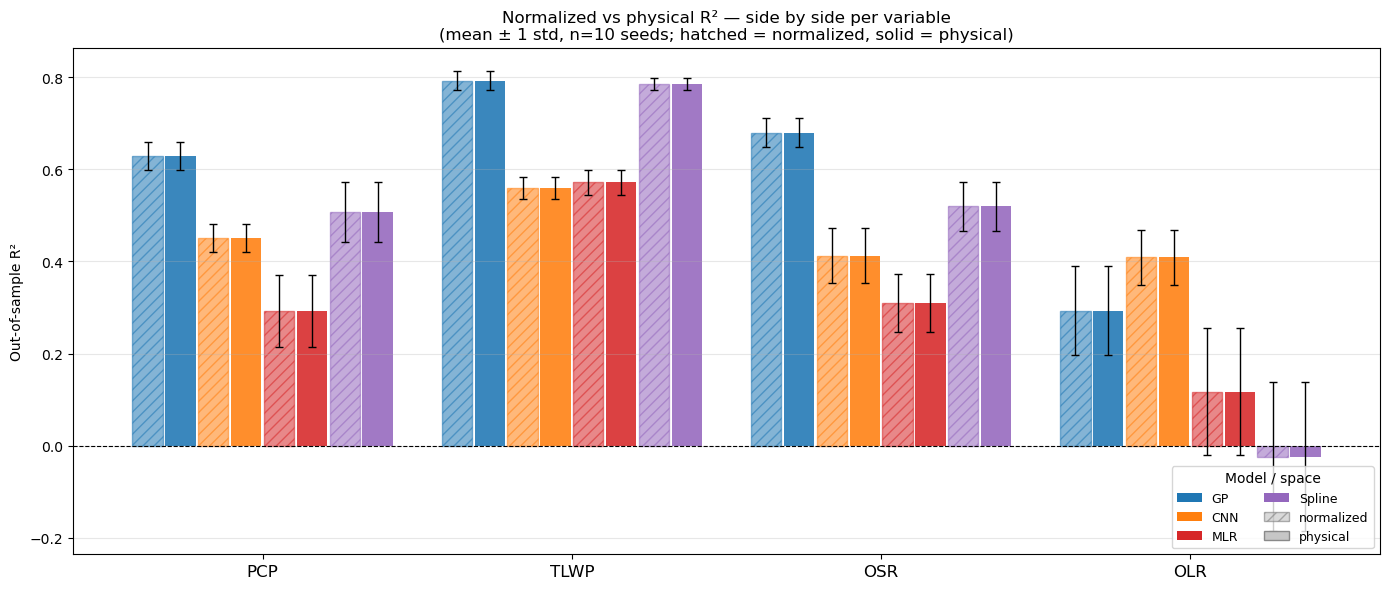

In [13]:
from matplotlib.patches import Patch

norm_models = [m for m in models_present if m != 'RF']

# slots per group: 2 per norm_model (norm + phys)
n_slots     = len(norm_models) * 2
group_width = 0.85
bar_w       = group_width / n_slots
x_base      = np.arange(len(VAR_NAMES))

fig, ax = plt.subplots(figsize=(14, 6))

for vi, var in enumerate(VAR_NAMES):
    for si, m in enumerate(norm_models):
        color  = colors_model.get(m, 'gray')
        x_left = x_base[vi] - group_width / 2 + bar_w / 2

        # normalized bar (hatched)
        col_n   = f'{var}_test_r2_norm'
        mean_n  = agg_mean.loc[m, col_n] if (col_n in agg_mean.columns and m in agg_mean.index) else np.nan
        std_n   = agg_std.loc[m,  col_n] if (col_n in agg_std.columns  and m in agg_std.index)  else 0
        xpos_n  = x_left + (2 * si) * bar_w
        ax.bar(xpos_n, mean_n, width=bar_w * 0.92, yerr=std_n,
               color=color, hatch='///', alpha=0.55, edgecolor=color,
               capsize=3, error_kw={'linewidth': 1.0})

        # physical bar (solid)
        col_p   = f'{var}_test_r2_phys'
        mean_p  = agg_mean.loc[m, col_p] if (col_p in agg_mean.columns and m in agg_mean.index) else np.nan
        std_p   = agg_std.loc[m,  col_p] if (col_p in agg_std.columns  and m in agg_std.index)  else 0
        xpos_p  = x_left + (2 * si + 1) * bar_w
        ax.bar(xpos_p, mean_p, width=bar_w * 0.92, yerr=std_p,
               color=color, hatch='', alpha=0.88,
               capsize=3, error_kw={'linewidth': 1.0})

ax.set_xticks(x_base)
ax.set_xticklabels(VAR_NAMES, fontsize=12)
ax.set_ylabel('Out-of-sample R²')
ax.set_title(
    f'Normalized vs physical R² — side by side per variable\n'
    f'(mean ± 1 std, n={n_seeds} seeds; hatched = normalized, solid = physical)',
    fontsize=12,
)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.grid(axis='y', alpha=0.3)

# Legend: one colour patch per model + hatch style indicator
model_patches = [Patch(facecolor=colors_model.get(m, 'gray'), label=m) for m in norm_models]
style_patches  = [
    Patch(facecolor='silver', hatch='///', edgecolor='gray', alpha=0.6, label='normalized'),
    Patch(facecolor='silver', hatch='',    edgecolor='gray', alpha=0.9, label='physical'),
]
ax.legend(handles=model_patches + style_patches, title='Model / space',
          ncol=2, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

In [14]:
print(agg_mean[['OLR_test_r2_norm', 'OLR_test_r2_phys']])


        OLR_test_r2_norm  OLR_test_r2_phys
model                                     
CNN             0.409085          0.409085
GP              0.292939          0.292939
MLR             0.117011          0.117011
RF                   NaN          0.272611
Spline         -0.024106         -0.024106


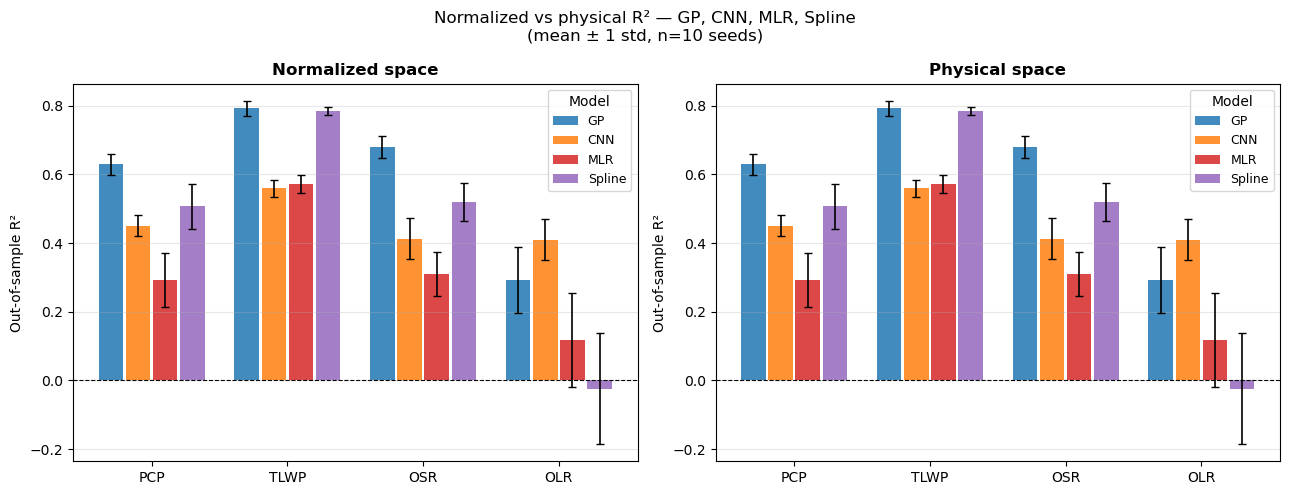

In [15]:
norm_models = [m for m in models_present if m not in ('RF',)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
titles = ['Normalized space', 'Physical space']
suffixes = ['_test_r2_norm', '_test_r2_phys']

for ax, title, suffix in zip(axes, titles, suffixes):
    x_pos = np.arange(len(VAR_NAMES))
    n_m   = len(norm_models)
    w     = 0.8 / n_m

    for i, m in enumerate(norm_models):
        col_check = f'PCP{suffix}'
        if col_check not in agg_mean.columns or m not in agg_mean.index:
            continue
        offsets = x_pos + (i - n_m / 2 + 0.5) * w
        means = [agg_mean.loc[m, f'{v}{suffix}'] for v in VAR_NAMES]
        stds  = [agg_std.loc[m, f'{v}{suffix}']  for v in VAR_NAMES]
        ax.bar(offsets, means, width=w * 0.9, yerr=stds,
               label=m, color=colors_model.get(m, 'gray'), alpha=0.85,
               capsize=3, error_kw={'linewidth': 1.2})

    ax.set_xticks(x_pos)
    ax.set_xticklabels(VAR_NAMES)
    ax.set_ylabel('Out-of-sample R²')
    ax.set_title(title, fontweight='bold')
    ax.legend(title='Model', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

fig.suptitle(f'Normalized vs physical R² — GP, CNN, MLR, Spline\n'
             f'(mean ± 1 std, n={n_seeds} seeds)', fontsize=12)
plt.tight_layout()
plt.show()

## Plot 4 — RMSE: one panel per variable
Out-of-sample RMSE in physical space. Lower is better.

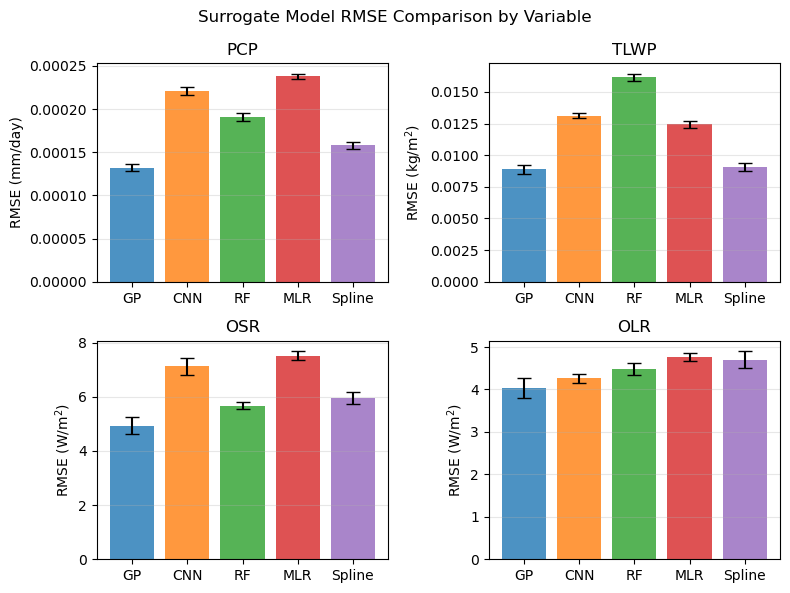

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharey=False)
axes = axes.flatten()
x = np.arange(len(models_present))

for ax, var in zip(axes, VAR_NAMES):
    col   = f'{var}_test_rmse_phys'
    scale = UNIT_SCALE.get(var, 1)
    means = [agg_mean.loc[m, col] * scale if col in agg_mean.columns and m in agg_mean.index else np.nan
             for m in models_present]
    stds  = [agg_std.loc[m, col] * scale  if col in agg_std.columns  and m in agg_std.index  else 0
             for m in models_present]

    bar_colors = [colors_model.get(m, 'gray') for m in models_present]
    ax.bar(x, means, yerr=stds, color=bar_colors, alpha=0.8,
           capsize=5, error_kw={'linewidth': 1.5})

    # overlay individual seed-mean dots
    for i, m in enumerate(models_present):
        if col not in seed_means.columns:
            continue
        pts = seed_means.loc[seed_means['model'] == m, col].values
        #ax.scatter(np.full(len(pts), i), pts, color='black', s=15, alpha=0.5, zorder=3)

    ax.set_title(var) #, fontweight='bold')
    ax.set_ylabel(f'RMSE ({UNITS[var]})')
    ax.set_xticks(x)
    ax.set_xticklabels(models_present)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'Surrogate Model RMSE Comparison by Variable') #: out-of-sample RMSE (physical space)\n'
             #f'(bars = mean, error bars = ±1 std, n={n_seeds} seeds)',
             #f'(bars = mean, error bars = ±1 std, dots = per-seed means, n={n_seeds} seeds)',
             #fontsize=12)
plt.tight_layout()
plt.show()

## Plot 5 — RMSE: all variables on one axes
Grouped bar chart — each group is a variable, bars are models.

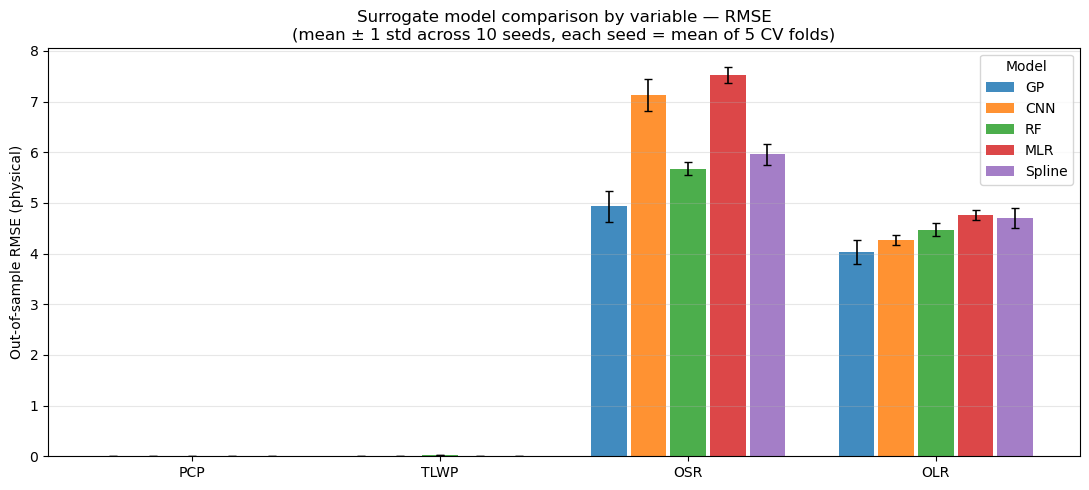

In [27]:
fig, ax = plt.subplots(figsize=(11, 5))

for i, m in enumerate(models_present):
    offsets = x_base + (i - n_models / 2 + 0.5) * width
    means, stds = [], []
    for var in VAR_NAMES:
        col = f'{var}_test_rmse_phys'
        means.append(agg_mean.loc[m, col] if col in agg_mean.columns and m in agg_mean.index else np.nan)
        stds.append(agg_std.loc[m, col]   if col in agg_std.columns  and m in agg_std.index  else 0)
    ax.bar(offsets, means, width=width * 0.9, yerr=stds,
           label=m, color=colors_model.get(m, 'gray'), alpha=0.85,
           capsize=3, error_kw={'linewidth': 1.2})

ax.set_xticks(x_base)
ax.set_xticklabels(VAR_NAMES)
ax.set_ylabel('Out-of-sample RMSE (physical)')
ax.set_title(f'Surrogate model comparison by variable — RMSE\n'
             f'(mean ± 1 std across {n_seeds} seeds, each seed = mean of 5 CV folds)')
ax.legend(title='Model')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Summary — 4 metrics, grouped by variable
Four bar charts (one per metric): x-axis = variable (PCP, TLWP, OSR, OLR), bars = models.  
Values are averaged first across folds within each seed, then across seeds.

In [ ]:
metrics_cfg = [
    ('R² — normalized',  '_test_r2_norm',   'Out-of-sample R² (normalized)'),
    ('R² — physical',    '_test_r2_phys',   'Out-of-sample R² (physical)'),
    ('RMSE — normalized','_test_rmse_norm',  'Out-of-sample RMSE (normalized)'),
    ('RMSE — physical',  '_test_rmse_phys',  'Out-of-sample RMSE (physical)'),
]

n_m   = len(models_present)
n_v   = len(VAR_NAMES)
w     = 0.8 / n_m
x_pos = np.arange(n_v)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (title, suffix, ylabel) in zip(axes, metrics_cfg):
    for i, m in enumerate(models_present):
        means, stds = [], []
        for var in VAR_NAMES:
            col = f'{var}{suffix}'
            means.append(agg_mean.loc[m, col] if col in agg_mean.columns and m in agg_mean.index else np.nan)
            stds.append( agg_std.loc[m, col]  if col in agg_std.columns  and m in agg_std.index  else 0)
        offsets = x_pos + (i - n_m / 2 + 0.5) * w
        ax.bar(offsets, means, width=w * 0.9, yerr=stds,
               label=m, color=colors_model.get(m, 'gray'), alpha=0.85,
               capsize=4, error_kw={'linewidth': 1.2})

    ax.set_xticks(x_pos)
    ax.set_xticklabels(VAR_NAMES)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(title='Model', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    if 'R²' in title:
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

fig.suptitle(
    f'Surrogate model comparison — all 4 metrics\n'
    f'(mean ± 1 std, n={n_seeds} seeds × 5 folds, averaged across folds then seeds)',
    fontsize=13,
)
plt.tight_layout()
plt.show()